# Experimentations Modele Lineaire - Dataset Dechets

- **Rosenblatt** (classification) applique au dataset reel (compost / dechets_chimiques / recyclable)


In [ ]:
# Imports
import sys
import os
import importlib
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets"
PY_DIR = "/Users/roissath/Documents/Cours 2025-2026/PA/projet_dechets/model_lineaire/code/py"

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, PY_DIR)

from charger_dataset import charger_config, labels_onehot

if 'linmodel_lib' in sys.modules:
    importlib.reload(sys.modules['linmodel_lib'])
from linmodel_lib import LinearModel

print("Imports OK")

Imports OK


## 0. Chargement du dataset et verification du bias de classe

In [2]:
CONFIG = "32x32_rgb"
X_train, y_train, X_val, y_val, X_test, y_test, classes = charger_config(CONFIG)

N_CLASSES  = len(classes)
N_FEATURES = X_train.shape[1]

print(f"Config      : {CONFIG}")
print(f"Classes     : {classes}")
print(f"N_FEATURES  : {N_FEATURES}   N_CLASSES : {N_CLASSES}")
print(f"X_train : {X_train.shape}   X_val : {X_val.shape}   X_test : {X_test.shape}")
print(f"Pixels normalises : min={X_train.min():.3f}  max={X_train.max():.3f}")

print("\nRepartition par classe (verifie l'equilibre / le biais du dataset) :")
for idx, c in enumerate(classes):
    n_tr = int(np.sum(y_train == idx))
    n_va = int(np.sum(y_val == idx))
    n_te = int(np.sum(y_test == idx))
    print(f"  {c:20s} : train={n_tr:5d}  val={n_va:5d}  test={n_te:5d}")

Config     : 32x32_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 3072)  y_train : (4960,)
  X_val   : (1062, 3072)    y_val   : (1062,)
  X_test  : (1066, 3072)   y_test  : (1066,)
  n_features = 3072
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

Config      : 32x32_rgb
Classes     : ['compost', 'dechets_chimiques', 'recyclable']
N_FEATURES  : 3072   N_CLASSES : 3
X_train : (4960, 3072)   X_val : (1062, 3072)   X_test : (1066, 3072)
Pixels normalises : min=0.000  max=1.000

Repartition par classe (verifie l'equilibre / le biais du dataset) :
  compost              : train= 1785  val=  382  test=  384
  dechets_chimiques    : train= 1742  val=  373  test=  374
  recyclable           : train= 1433  val=  307  test=  3

## Fonctions d'experimentation

In [ ]:
def train_curve(X_train, y_train, X_val, y_val, n_features, n_classes,
                 lr, max_epochs, step, seed=0):
    epochs_x = list(range(step, max_epochs + 1, step))
    hist_train, hist_val = [], []
    model = None
    for ep in epochs_x:
        model = LinearModel([n_features, n_classes], learning_rate=lr, max_ep=ep, seed=seed)
        loss_train = model.train(X_train, y_train)
        loss_val = model.loss(X_val, y_val)
        hist_train.append(loss_train)
        hist_val.append(loss_val)
    return epochs_x, hist_train, hist_val, model


def run_multiple(X_train, y_train, X_val, y_val, n_features, n_classes,
                  lr, max_epochs, n_runs=5):
    """
    Entraine n_runs modeles independants (seeds differents) sur UNE configuration
    fixe (lr, max_epochs) pour estimer la variance liee a l'initialisation aleatoire /
    a l'ordre de presentation des exemples. Beaucoup plus leger qu'un sweep complet
    repete n_runs fois (5 entrainements au lieu de 5 x 25).
    """
    accs, losses_val, models = [], [], []
    for run in range(n_runs):
        model = LinearModel([n_features, n_classes], learning_rate=lr, max_ep=max_epochs, seed=run)
        model.train(X_train, y_train)
        accs.append(model.accuracy(X_val, y_val))
        losses_val.append(model.loss(X_val, y_val))
        models.append(model)
    accs = np.array(accs)
    losses_val = np.array(losses_val)
    best_idx = int(np.argmax(accs))
    return {
        "models": models,
        "best_model": models[best_idx],
        "acc_mean": accs.mean(), "acc_std": accs.std(),
        "loss_mean": losses_val.mean(), "loss_std": losses_val.std(),
        "accs": accs,
    }

## 1. Impact du learning rate

In [4]:
LR_VALUES = [0.00001, 0.0001, 0.0005, 0.001, 0.01, 0.05]
N_EPOCHS_LR = 500
STEP_LR = 20
N_SEEDS_LR = 5              # memes seeds pour chaque LR -> comparaison loyale
DIVERGENCE_THRESHOLD = 10.0  # loss finale au-dela de ce seuil = LR instable

lr_results = {}
for lr in LR_VALUES:
    # 1 courbe (seed=0) pour le diagnostic visuel de convergence
    epochs_x, hist_train, hist_val, _ = train_curve(
        X_train, y_train, X_val, y_val, N_FEATURES, N_CLASSES,
        lr=lr, max_epochs=N_EPOCHS_LR, step=STEP_LR, seed=0
    )

    # N_SEEDS_LR runs (memes seeds pour tous les LR) pour une accuracy moyenne fiable
    accs = []
    for seed in range(N_SEEDS_LR):
        model = LinearModel([N_FEATURES, N_CLASSES], learning_rate=lr, max_ep=N_EPOCHS_LR, seed=seed)
        model.train(X_train, y_train)
        accs.append(model.accuracy(X_val, y_val))
    accs = np.array(accs)

    lr_results[lr] = {
        "epochs_x": epochs_x, "hist_train": hist_train, "hist_val": hist_val,
        "acc_mean": accs.mean(), "acc_std": accs.std(), "loss_val": hist_val[-1],
        "diverge": hist_val[-1] > DIVERGENCE_THRESHOLD,
    }
    status = "DIVERGE" if lr_results[lr]["diverge"] else "stable"
    print(f"lr={lr:<10} loss_val={hist_val[-1]:>12.4f}  "
          f"acc_val={accs.mean()*100:5.1f}% +/- {accs.std()*100:4.1f}%  [{status}]  ({N_SEEDS_LR} seeds)")

lr=1e-05      loss_val=      0.3286  acc_val= 54.8% +/-  2.9%  [stable]  (5 seeds)
lr=0.0001     loss_val=      0.3056  acc_val= 54.8% +/-  2.9%  [stable]  (5 seeds)
lr=0.0005     loss_val=      0.6394  acc_val= 54.8% +/-  2.9%  [stable]  (5 seeds)
lr=0.001      loss_val=      2.0571  acc_val= 54.8% +/-  2.9%  [stable]  (5 seeds)
lr=0.01       loss_val=    217.6636  acc_val= 54.8% +/-  2.9%  [DIVERGE]  (5 seeds)
lr=0.05       loss_val=   5533.4786  acc_val= 54.8% +/-  2.9%  [DIVERGE]  (5 seeds)


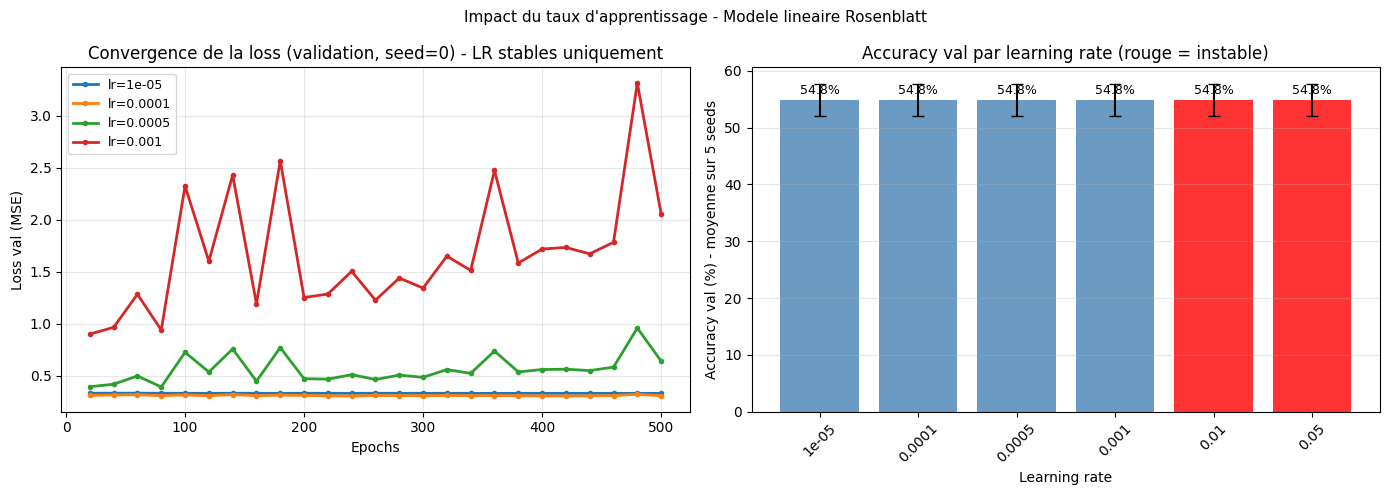

Ecart d'accuracy entre LR stables : 0.00 points (quasi nul -> confirme l'invariance du perceptron au LR)

Meilleur LR (stable, depage par loss) : 0.0001  (acc_val = 54.8% +/- 2.9%,  loss_val = 0.3056)
LR instables (divergent) : [0.01, 0.05]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Impact du taux d'apprentissage - Modele lineaire Rosenblatt", fontsize=11)

# Graphique 1 : Convergence (SANS les LR qui divergent, pour voir les details)
for lr, res in lr_results.items():
    if not res["diverge"]:
        axes[0].plot(res["epochs_x"], res["hist_val"], linewidth=2, marker='o', markersize=3, label=f"lr={lr}")
axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss val (MSE)")
axes[0].set_title("Convergence de la loss (validation, seed=0) - LR stables uniquement")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Graphique 2 : Barres d'accuracy MOYENNE +/- ecart-type (N_SEEDS_LR runs)
lrs = list(lr_results.keys())
means = [lr_results[lr]["acc_mean"] * 100 for lr in lrs]
stds  = [lr_results[lr]["acc_std"] * 100 for lr in lrs]
colors = ['red' if lr_results[lr]["diverge"] else 'steelblue' for lr in lrs]
bars = axes[1].bar([str(lr) for lr in lrs], means, yerr=stds, capsize=4, color=colors, alpha=0.8)
axes[1].set_xlabel("Learning rate"); axes[1].set_ylabel(f"Accuracy val (%) - moyenne sur {N_SEEDS_LR} seeds")
axes[1].set_title("Accuracy val par learning rate (rouge = instable)")
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(alpha=0.3, axis='y')

for bar, acc in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{acc:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("exp_comparaison_lr.png", dpi=130, bbox_inches='tight')
plt.show()

stable = {lr: r for lr, r in lr_results.items() if not r["diverge"]}

# L'accuracy est quasi-identique entre LR stables : propriete du perceptron initialise a W=0
# (le LR ne fait que rescaler W, sans changer l'argmax -> meme classification, meme accuracy).
# On depage donc par la loss_val (plus basse = poids mieux conditionnes numeriquement),
# plutot que par acc_mean qui ne discrimine pas.
BEST_LR = min(stable, key=lambda lr: stable[lr]["loss_val"])

acc_spread = max(r["acc_mean"] for r in stable.values()) - min(r["acc_mean"] for r in stable.values())
if acc_spread < 0.01:
    verdict = "quasi nul -> confirme l'invariance du perceptron au LR"
else:
    verdict = "non negligeable"
print(f"Ecart d'accuracy entre LR stables : {acc_spread*100:.2f} points ({verdict})")
print(f"\nMeilleur LR (stable, depage par loss) : {BEST_LR}"
      f"  (acc_val = {stable[BEST_LR]['acc_mean']*100:.1f}% +/- {stable[BEST_LR]['acc_std']*100:.1f}%,"
      f"  loss_val = {stable[BEST_LR]['loss_val']:.4f})")
print(f"LR instables (divergent) : {[lr for lr, r in lr_results.items() if r['diverge']]}")


## 2. Impact du nombre d'epochs

In [6]:
PALIERS = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
N_SEEDS_EPOCH = 5  # un seul seed peut faire gagner le mauvais palier par hasard (verifie plus tot)

epoch_results = {}
for ep in PALIERS:
    accs = []
    for seed in range(N_SEEDS_EPOCH):
        model = LinearModel([N_FEATURES, N_CLASSES], learning_rate=BEST_LR, max_ep=ep, seed=seed)
        model.train(X_train, y_train)
        accs.append(model.accuracy(X_val, y_val))
    accs = np.array(accs)
    epoch_results[ep] = {"acc_mean": accs.mean(), "acc_std": accs.std(), "accs": accs}
    print(f"epochs={ep:3d}  acc_val = {accs.mean()*100:5.1f}% +/- {accs.std()*100:4.1f}%  ({N_SEEDS_EPOCH} seeds)")

BEST_EPOCHS = max(epoch_results, key=lambda ep: epoch_results[ep]["acc_mean"])
print(f"\nMeilleur nombre d'epochs (moyenne sur {N_SEEDS_EPOCH} seeds) : {BEST_EPOCHS}"
      f"  (acc_val = {epoch_results[BEST_EPOCHS]['acc_mean']*100:.1f}%"
      f" +/- {epoch_results[BEST_EPOCHS]['acc_std']*100:.1f}%)")

epochs= 50  acc_val =  48.9% +/-  7.3%  (5 seeds)
epochs=100  acc_val =  48.5% +/-  2.9%  (5 seeds)
epochs=150  acc_val =  52.9% +/-  5.1%  (5 seeds)
epochs=200  acc_val =  50.7% +/-  8.4%  (5 seeds)
epochs=250  acc_val =  55.5% +/-  1.8%  (5 seeds)
epochs=300  acc_val =  52.8% +/-  3.6%  (5 seeds)
epochs=350  acc_val =  53.7% +/-  2.4%  (5 seeds)
epochs=400  acc_val =  52.1% +/-  3.5%  (5 seeds)
epochs=450  acc_val =  52.3% +/-  5.0%  (5 seeds)
epochs=500  acc_val =  54.8% +/-  2.9%  (5 seeds)

Meilleur nombre d'epochs (moyenne sur 5 seeds) : 250  (acc_val = 55.5% +/- 1.8%)


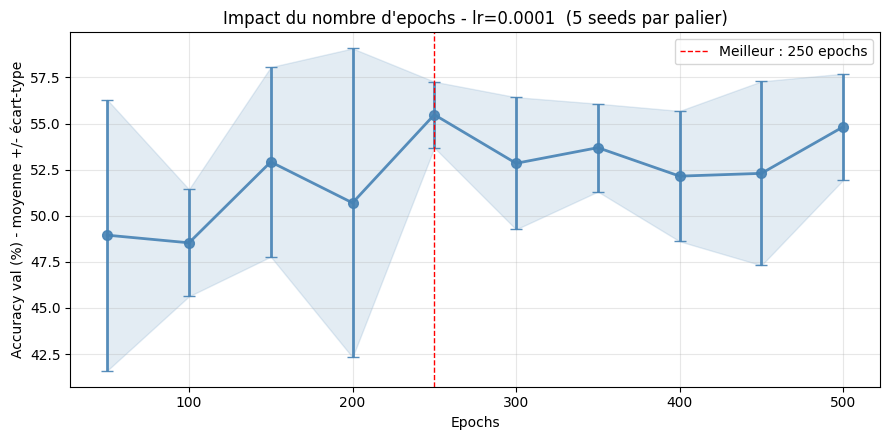

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
paliers = list(epoch_results.keys())
means = np.array([epoch_results[e]["acc_mean"] * 100 for e in paliers])
stds  = np.array([epoch_results[e]["acc_std"]  * 100 for e in paliers])

ax.errorbar(paliers, means, yerr=stds, color='steelblue', linewidth=2,
            marker='o', markersize=7, capsize=4, ecolor='steelblue', alpha=0.9)
ax.fill_between(paliers, means - stds, means + stds, color='steelblue', alpha=0.15)
ax.axvline(BEST_EPOCHS, color='red', linestyle='--', linewidth=1, label=f"Meilleur : {BEST_EPOCHS} epochs")
ax.set_xlabel("Epochs"); ax.set_ylabel("Accuracy val (%) - moyenne +/- écart-type")
ax.set_title(f"Impact du nombre d'epochs - lr={BEST_LR}  ({N_SEEDS_EPOCH} seeds par palier)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("exp_impact_epochs.png", dpi=130, bbox_inches='tight')
plt.show()

## 3. Modele final robuste (moyenne sur plusieurs seeds)

Le modele lineaire est sensible au seed (ordre de presentation des exemples dans Rosenblatt).
On entraine ici 5 modeles independants sur la configuration retenue (`BEST_LR`, `BEST_EPOCHS`)
pour reporter une accuracy moyenne +/- ecart-type plutot qu'un chiffre issu d'un seul run
qui peut etre un coup de chance ou de malchance.

In [8]:
N_RUNS = 5

robust = run_multiple(X_train, y_train, X_val, y_val, N_FEATURES, N_CLASSES,
                       lr=BEST_LR, max_epochs=BEST_EPOCHS, n_runs=N_RUNS)

best_model = robust["best_model"]
acc_rgb_ref = best_model.accuracy(X_val, y_val)

print(f"Configuration retenue : lr={BEST_LR}, epochs={BEST_EPOCHS}, {N_RUNS} runs (seeds 0..{N_RUNS-1})")
print(f"Accuracy val : {robust['acc_mean']*100:.1f}% +/- {robust['acc_std']*100:.1f}%  (sur {N_RUNS} runs)")
print(f"Loss val     : {robust['loss_mean']:.4f} +/- {robust['loss_std']:.4f}")
print(f"Modele retenu pour la suite : run avec la meilleure accuracy val ({acc_rgb_ref*100:.1f}%)")

Configuration retenue : lr=0.0001, epochs=250, 5 runs (seeds 0..4)
Accuracy val : 55.5% +/- 1.8%  (sur 5 runs)
Loss val     : 0.3057 +/- 0.0030
Modele retenu pour la suite : run avec la meilleure accuracy val (57.5%)


## 4. Comparaison des representations (couleur / resolution)

In [9]:
X_train_g, y_train_g, X_val_g, y_val_g, X_test_g, y_test_g, _ = charger_config("32x32_gris")
N_FEATURES_G = X_train_g.shape[1]

robust_gris = run_multiple(X_train_g, y_train_g, X_val_g, y_val_g, N_FEATURES_G, N_CLASSES,
                            lr=BEST_LR, max_epochs=BEST_EPOCHS, n_runs=N_RUNS)
model_gris = robust_gris["best_model"]
acc_gris = robust_gris["acc_mean"]

print(f"32x32 gris ({N_FEATURES_G} features) : acc_val = {robust_gris['acc_mean']*100:.1f}% +/- {robust_gris['acc_std']*100:.1f}%  ({N_RUNS} runs)")
print(f"32x32 rgb  ({N_FEATURES} features)  : acc_val = {robust['acc_mean']*100:.1f}% +/- {robust['acc_std']*100:.1f}%  ({N_RUNS} runs)")
print(f"Difference (moyennes) : {(acc_gris-acc_rgb_ref)*100:+.1f} points")

Config     : 32x32_gris
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 1024)  y_train : (4960,)
  X_val   : (1062, 1024)    y_val   : (1062,)
  X_test  : (1066, 1024)   y_test  : (1066,)
  n_features = 1024
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

32x32 gris (1024 features) : acc_val = 47.0% +/- 0.7%  (5 runs)
32x32 rgb  (3072 features)  : acc_val = 55.5% +/- 1.8%  (5 runs)
Difference (moyennes) : -10.5 points


In [10]:
X_train_64, y_train_64, X_val_64, y_val_64, X_test_64, y_test_64, _ = charger_config("64x64_rgb")
N_FEATURES_64 = X_train_64.shape[1]

robust_64 = run_multiple(X_train_64, y_train_64, X_val_64, y_val_64, N_FEATURES_64, N_CLASSES,
                          lr=BEST_LR, max_epochs=BEST_EPOCHS, n_runs=N_RUNS)
model_64 = robust_64["best_model"]
acc_64 = robust_64["acc_mean"]

print(f"64x64 rgb  ({N_FEATURES_64} features) : acc_val = {robust_64['acc_mean']*100:.1f}% +/- {robust_64['acc_std']*100:.1f}%  ({N_RUNS} runs)")
print(f"32x32 rgb  ({N_FEATURES} features)   : acc_val = {robust['acc_mean']*100:.1f}% +/- {robust['acc_std']*100:.1f}%  ({N_RUNS} runs)")
print(f"Difference (moyennes) : {(acc_64-acc_rgb_ref)*100:+.1f} points")

n_train = X_train.shape[0]
ratio_32 = n_train / (N_FEATURES * N_CLASSES)
ratio_64 = n_train / (N_FEATURES_64 * N_CLASSES)
print(f"\nRatio exemples/parametres (regle du cours : viser >= 10x pour bien generaliser) :")
print(f"  32x32 rgb : {ratio_32:.2f}x")
print(f"  64x64 rgb : {ratio_64:.2f}x")

Config     : 64x64_rgb
Classes    : ['compost', 'dechets_chimiques', 'recyclable']
Chargement en cours...

Dimensions :
  X_train : (4960, 12288)  y_train : (4960,)
  X_val   : (1062, 12288)    y_val   : (1062,)
  X_test  : (1066, 12288)   y_test  : (1066,)
  n_features = 12288
  Pixels normalises dans [0, 1] : min=0.000  max=1.000

Repartition par classe :
  compost              : train=1785  val=382  test=384
  dechets_chimiques    : train=1742  val=373  test=374
  recyclable           : train=1433  val=307  test=308

64x64 rgb  (12288 features) : acc_val = 58.3% +/- 3.7%  (5 runs)
32x32 rgb  (3072 features)   : acc_val = 55.5% +/- 1.8%  (5 runs)
Difference (moyennes) : +0.8 points

Ratio exemples/parametres (regle du cours : viser >= 10x pour bien generaliser) :
  32x32 rgb : 0.54x
  64x64 rgb : 0.13x


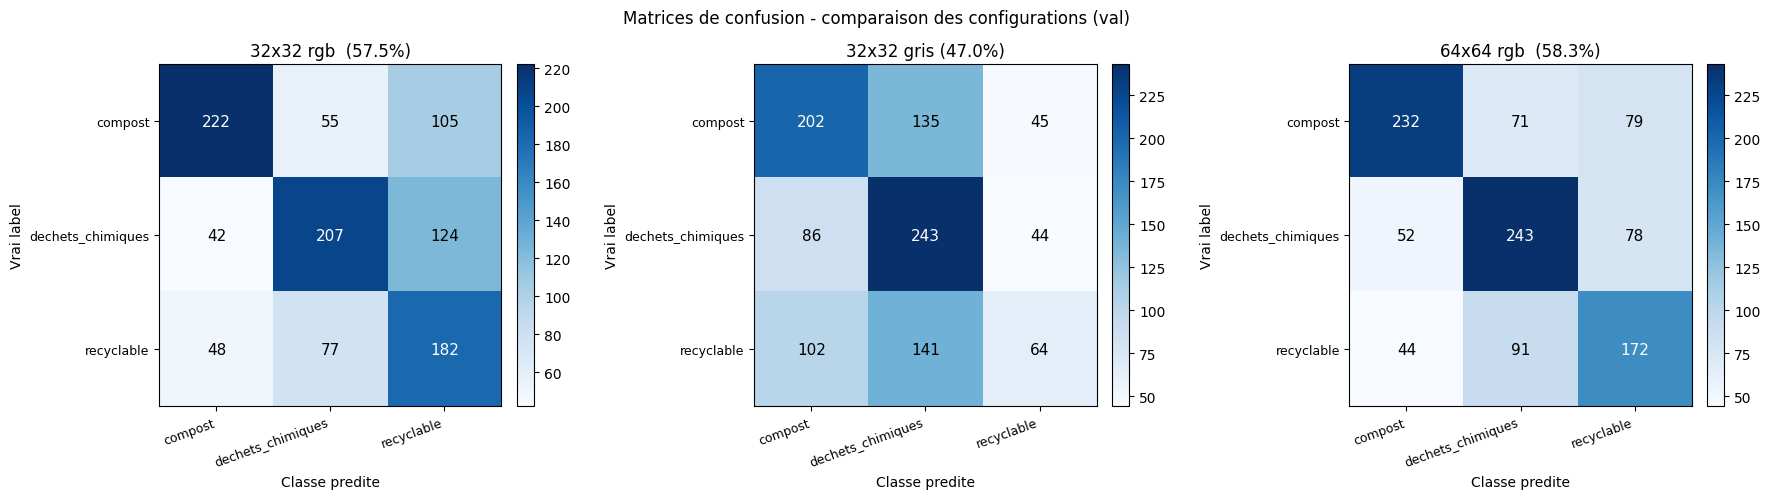

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de confusion - comparaison des configurations (val)", fontsize=12)

configs_cm = [
    (best_model, X_val,    y_val,    f"32x32 rgb  ({acc_rgb_ref*100:.1f}%)"),
    (model_gris, X_val_g,  y_val_g,  f"32x32 gris ({acc_gris*100:.1f}%)"),
    (model_64,   X_val_64, y_val_64, f"64x64 rgb  ({acc_64*100:.1f}%)"),
]

for ax, (model, X_v, y_v, titre) in zip(axes, configs_cm):
    cm = model.confusion_matrix(X_v, y_v)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
    ax.set_yticklabels(classes, fontsize=9)
    ax.set_xlabel("Classe predite"); ax.set_ylabel("Vrai label")
    ax.set_title(titre)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            couleur = 'white' if cm[i, j] > cm.max() * 0.6 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=couleur, fontsize=11)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("exp_matrices_confusion.png", dpi=130, bbox_inches='tight')
plt.show()

## 5. Evaluation finale sur le test set

Le validation set a servi a choisir les hyperparametres (LR, epochs). Pour une evaluation
non biaisee, on calcule l'accuracy sur le **test set**, jamais vu pendant la selection.

In [12]:
print("=" * 60)
print("        EVALUATION FINALE SUR LE TEST SET")
print("=" * 60)

final_configs = {
    "32x32 rgb":  (best_model, X_train, y_train, X_val, y_val, X_test, y_test),
    "32x32 gris": (model_gris, X_train_g, y_train_g, X_val_g, y_val_g, X_test_g, y_test_g),
    "64x64 rgb":  (model_64, X_train_64, y_train_64, X_val_64, y_val_64, X_test_64, y_test_64),
}

test_summary = {}
for name, (model, Xtr, ytr, Xv, yv, Xte, yte) in final_configs.items():
    acc_tr, acc_v, acc_te = model.accuracy(Xtr, ytr), model.accuracy(Xv, yv), model.accuracy(Xte, yte)
    test_summary[name] = {"train": acc_tr, "val": acc_v, "test": acc_te}
    print(f"\n{name} :")
    print(f"  Accuracy TRAIN : {acc_tr*100:5.1f}%")
    print(f"  Accuracy VAL   : {acc_v*100:5.1f}%")
    print(f"  Accuracy TEST  : {acc_te*100:5.1f}%   <- performance finale non biaisee")

best_config = max(test_summary, key=lambda k: test_summary[k]["test"])
print(f"\nMeilleure configuration (sur test) : {best_config}  ({test_summary[best_config]['test']*100:.1f}%)")

        EVALUATION FINALE SUR LE TEST SET

32x32 rgb :
  Accuracy TRAIN :  75.5%
  Accuracy VAL   :  57.5%
  Accuracy TEST  :  55.9%   <- performance finale non biaisee

32x32 gris :
  Accuracy TRAIN :  62.9%
  Accuracy VAL   :  47.9%
  Accuracy TEST  :  48.1%   <- performance finale non biaisee

64x64 rgb :
  Accuracy TRAIN :  95.8%
  Accuracy VAL   :  60.9%
  Accuracy TEST  :  57.6%   <- performance finale non biaisee

Meilleure configuration (sur test) : 64x64 rgb  (57.6%)


## 6. Sauvegarde du modele final

In [13]:
best_model.save("meilleur_modele_lineaire.txt")
print("Modele sauvegarde dans meilleur_modele_lineaire.txt")

model_reloaded = LinearModel.load("meilleur_modele_lineaire.txt")
acc_check = model_reloaded.accuracy(X_test, y_test)
print(f"Accuracy test (modele recharge) : {acc_check*100:.1f}%  (doit etre identique a l'accuracy test du modele original)")

Modele sauvegarde dans meilleur_modele_lineaire.txt
Accuracy test (modele recharge) : 55.9%  (doit etre identique a l'accuracy test du modele original)


## 5bis. Recapitulatif visuel final

Accuracy **test** des 3 configurations en un seul graphe, avec l'ecart-type mesure sur les runs
multiples (sections 3/4), compare a la ligne du hasard (33.3%).

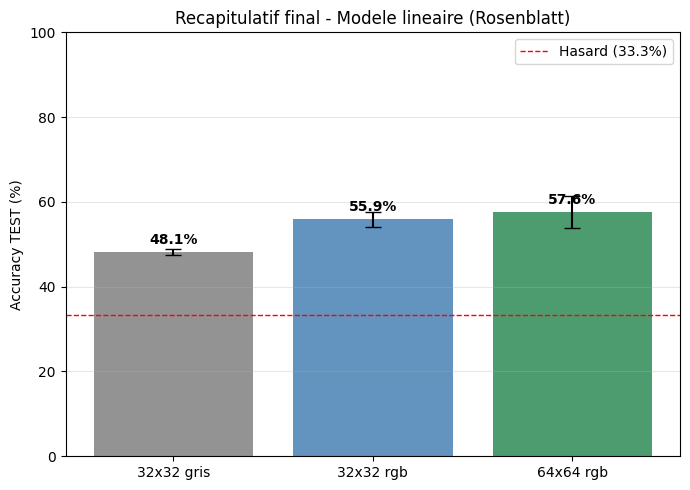

Meilleure config : 64x64 rgb -> 57.6% (test)
Gain par rapport au hasard : +24.3 points


In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

recap_names = ["32x32 gris", "32x32 rgb", "64x64 rgb"]
recap_test  = [test_summary[n]["test"] * 100 for n in recap_names]
recap_std   = [robust_gris["acc_std"] * 100, robust["acc_std"] * 100, robust_64["acc_std"] * 100]
recap_colors = ['gray', 'steelblue', 'seagreen']

bars = ax.bar(recap_names, recap_test, yerr=recap_std, capsize=6, color=recap_colors, alpha=0.85)
ax.axhline(100/N_CLASSES, color='red', linestyle='--', linewidth=1, label=f"Hasard ({100/N_CLASSES:.1f}%)")

for bar, acc in zip(bars, recap_test):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{acc:.1f}%",
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel("Accuracy TEST (%)")
ax.set_title("Recapitulatif final - Modele lineaire (Rosenblatt)")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("exp_recapitulatif_final.png", dpi=130, bbox_inches='tight')
plt.show()

print(f"Meilleure config : {best_config} -> {test_summary[best_config]['test']*100:.1f}% (test)")
print(f"Gain par rapport au hasard : {(test_summary[best_config]['test'] - 1/N_CLASSES)*100:+.1f} points")

## Conclusion

In [15]:
print("=" * 60)
print("CONCLUSION - generee automatiquement a partir de cette execution")
print("=" * 60)

print(f"\n1. Impact du learning rate ({len(LR_VALUES)} valeurs testees) :")
for lr, r in lr_results.items():
    status = "DIVERGE" if r["diverge"] else ("BEST" if lr == BEST_LR else "stable")
    print(f"   lr={lr:<10} acc_val={r['acc_mean']*100:5.1f}% +/- {r['acc_std']*100:4.1f}%   [{status}]")

print(f"\n2. Impact du nombre d'epochs (lr={BEST_LR}) :")
print(f"   Meilleur : {BEST_EPOCHS} epochs -> {epoch_results[BEST_EPOCHS]['acc_mean']*100:.1f}%")

print(f"\n3. Robustesse (n={N_RUNS} runs, lr={BEST_LR}, epochs={BEST_EPOCHS}) :")
print(f"   acc_val = {robust['acc_mean']*100:.1f}% +/- {robust['acc_std']*100:.1f}%")

print(f"\n4. Comparaison des representations (accuracy test) :")
for name, s in test_summary.items():
    print(f"   {name:12s} : {s['test']*100:5.1f}%")

print(f"\n5. Performance finale retenue : {best_config} -> {test_summary[best_config]['test']*100:.1f}% (test set)")

CONCLUSION - generee automatiquement a partir de cette execution

1. Impact du learning rate (6 valeurs testees) :
   lr=1e-05      acc_val= 54.8% +/-  2.9%   [stable]
   lr=0.0001     acc_val= 54.8% +/-  2.9%   [BEST]
   lr=0.0005     acc_val= 54.8% +/-  2.9%   [stable]
   lr=0.001      acc_val= 54.8% +/-  2.9%   [stable]
   lr=0.01       acc_val= 54.8% +/-  2.9%   [DIVERGE]
   lr=0.05       acc_val= 54.8% +/-  2.9%   [DIVERGE]

2. Impact du nombre d'epochs (lr=0.0001) :
   Meilleur : 250 epochs -> 55.5%

3. Robustesse (n=5 runs, lr=0.0001, epochs=250) :
   acc_val = 55.5% +/- 1.8%

4. Comparaison des representations (accuracy test) :
   32x32 rgb    :  55.9%
   32x32 gris   :  48.1%
   64x64 rgb    :  57.6%

5. Performance finale retenue : 64x64 rgb -> 57.6% (test set)


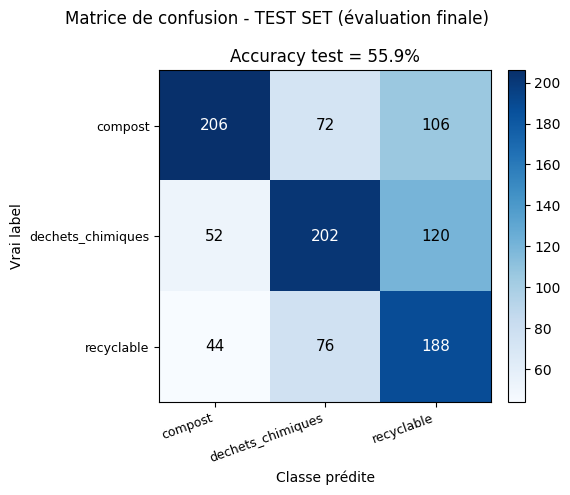

Matrice de confusion (TEST) :
                            compost  dechets_  recyclab
  compost                      206        72       106
  dechets_chimiques             52       202       120
  recyclable                    44        76       188

Confusion la plus fréquente : 'dechets_chimiques' prédit comme 'recyclable' (120 cas)


In [16]:
# Matrice de confusion FINALE - sur le TEST SET, pour le meilleur modèle (32x32 rgb)
# Calculée une seule fois, sur des données jamais vues pendant l'exploration (LR / epochs)

cm_test = best_model.confusion_matrix(X_test, y_test)
acc_test_rgb = test_summary["32x32 rgb"]["test"]

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Matrice de confusion - TEST SET (évaluation finale)", fontsize=12)

im = ax.imshow(cm_test, cmap='Blues')
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(classes, rotation=20, ha='right', fontsize=9)
ax.set_yticklabels(classes, fontsize=9)
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Vrai label")
ax.set_title(f"Accuracy test = {acc_test_rgb*100:.1f}%")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        couleur = 'white' if cm_test[i, j] > cm_test.max() * 0.6 else 'black'
        ax.text(j, i, str(cm_test[i, j]),
                ha='center', va='center',
                color=couleur, fontsize=11)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig("exp_matrice_confusion_test_final.png", dpi=130, bbox_inches='tight')
plt.show()

# Lecture chiffrée, utile à coller directement dans le rapport
print("Matrice de confusion (TEST) :")
print(f"{'':25s}", end="")
for c in classes:
    print(f"{c[:8]:>10s}", end="")
print()
for i, c in enumerate(classes):
    print(f"  {c:22s}", end="")
    for j in range(N_CLASSES):
        print(f"{cm_test[i, j]:>10d}", end="")
    print()

# Identifie automatiquement la confusion la plus fréquente (hors diagonale)
cm_off_diag = cm_test.copy()
np.fill_diagonal(cm_off_diag, 0)
i_max, j_max = np.unravel_index(np.argmax(cm_off_diag), cm_off_diag.shape)
if cm_off_diag[i_max, j_max] > 0:
    print(f"\nConfusion la plus fréquente : '{classes[i_max]}' prédit comme '{classes[j_max]}' "
          f"({cm_off_diag[i_max, j_max]} cas)")

### Discussion (a completer avec les chiffres reels obtenus ci-dessus)

- **Learning rate** : la zone stable se situe parmi les LR qui ne divergent pas (loss finale sous le seuil). Au-dela, la mise a jour de Rosenblatt (`W += alpha * (Y-g(X)) * X`) devient trop agressive et la loss explose.
- **Nombre d'epochs** : le modele lineaire converge rapidement - attendu, vu la simplicite de l'hypothese (une seule frontiere lineaire par classe, pas de non-linearite a apprendre).
- **Robustesse** : l'ecart-type mesure sur les 5 runs quantifie l'impact du seed (ordre de presentation des exemples) sur le resultat - a mentionner comme limite methodologique dans le rapport.
- **Representations (gris / rgb / resolution)** : comparer les accuracy test ci-dessus. Si le 64x64 fait moins bien que le 32x32 malgre plus d'information, relier cela au ratio exemples/parametres calcule plus haut et a la regle du cours (slide 58) : viser au moins 10x plus d'exemples que de parametres pour esperer generaliser correctement.
- **Limites du modele lineaire** : l'accuracy plafonne loin de 100% sur cette tache de classification d'image - attendu, une frontiere lineaire dans l'espace des pixels bruts est une hypothese trop simple (sous-apprentissage structurel) pour ce type de probleme. C'est precisement ce qu'un PMC (avec ses couches non lineaires) est cense ameliorer.
- **Biais dans la base d'exemples** : la repartition des classes (section 0) montre le niveau d'equilibre du dataset entre compost / dechets_chimiques / recyclable - a commenter comme source potentielle de biais si l'ecart est marque.